In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

In [ ]:
PERIOD = '2y'              # 6mo, 1y, 2y, 5y, max
BENCHMARK = 'VT'           # benchmark ticker
RF_RATE = 0.00             # risk-free rate (annualized)

weights = pd.read_csv('../data/processed/portfolio_weights.csv', index_col=0)
weights

In [58]:
# Fetch price data for portfolio holdings + benchmark
tickers = weights['symbol'].tolist()
all_tickers = tickers + [BENCHMARK] if BENCHMARK not in tickers else tickers

prices = yf.download(all_tickers, period=PERIOD, auto_adjust=True)['Close']
prices = prices.dropna(how='all').ffill()

# Fetch FX rates to convert everything to CHF
fx = yf.download(['USDCHF=X', 'GBPCHF=X'], period=PERIOD, auto_adjust=True)['Close']
fx = fx.reindex(prices.index).ffill().bfill()

# Currency mapping per ticker
currency_map = {
    'AVEM': 'USD', 'BOXX': 'USD', 'DXIV': 'USD', 'DXUV': 'USD', 'VT': 'USD',
    'GLAC': 'CHF', 'SPMCHA.SW': 'CHF',
    '0P0001UA1S.L': 'GBP',
}
fx_rate = {'USD': fx['USDCHF=X'], 'GBP': fx['GBPCHF=X'], 'CHF': 1}

# Convert all prices to CHF
prices_chf = prices.copy()
for col in prices_chf.columns:
    ccy = currency_map.get(col, 'USD')
    if ccy != 'CHF':
        prices_chf[col] = prices_chf[col] * fx_rate[ccy]

# Drop tickers that failed to download (all NaN columns)
available = [t for t in tickers if t in prices_chf.columns and prices_chf[t].notna().any()]
missing = set(tickers) - set(available)
if missing:
    print(f'WARNING: missing tickers excluded: {missing}')

# Re-normalise weights to available tickers only
w = weights.set_index('symbol')['weight'].reindex(available).fillna(0)
w = w / w.sum()

# Portfolio daily returns (weighted sum) — fill NaN returns with 0 for non-trading days
asset_returns = prices_chf.pct_change()
asset_returns = asset_returns.iloc[1:]  # drop first row (all NaN from pct_change)
port_returns = asset_returns[available].fillna(0).dot(w[available])
bench_returns = asset_returns[BENCHMARK].dropna()

# Align portfolio and benchmark to common dates
common = port_returns.index.intersection(bench_returns.index)
port_returns = port_returns.loc[common]
bench_returns = bench_returns.loc[common]

port_cum = (1 + port_returns).cumprod()
bench_cum = (1 + bench_returns).cumprod()

print(f'Loaded {len(prices)} trading days for {len(available)}/{len(tickers)} holdings + benchmark')
print('All prices converted to CHF')

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  2 of 2 completed

Loaded 517 trading days for 7/7 holdings + benchmark
All prices converted to CHF


## Performance vs Benchmark

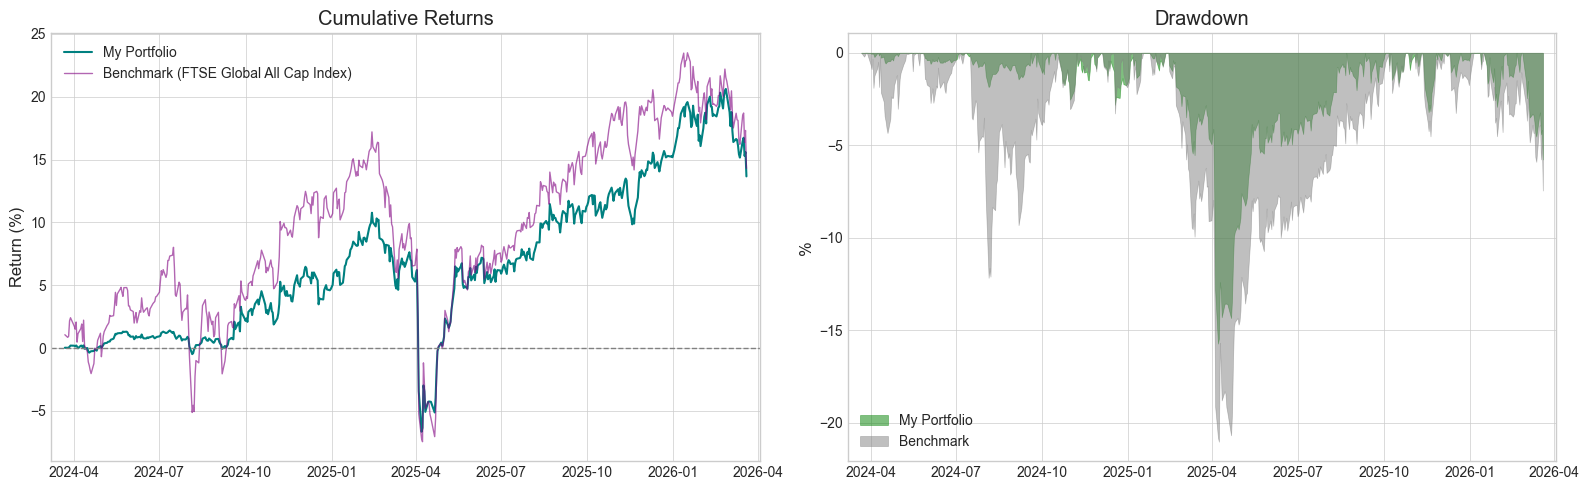

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative returns
ax = axes[0]
ax.plot((port_cum - 1) * 100, label='My Portfolio', linewidth=1.5, color='teal')
ax.plot((bench_cum - 1) * 100, label='Benchmark (FTSE Global All Cap Index)', linewidth=1, alpha=0.6, color='purple')
ax.axhline(0, color='grey', ls='--', lw=1)
ax.set_title('Cumulative Returns')
ax.set_ylabel('Return (%)')
ax.legend()

# Drawdown
ax = axes[1]
for series, label, color in [(port_cum, 'My Portfolio', 'green'), (bench_cum, 'Benchmark', 'gray')]:
    dd = series / series.expanding().max() - 1
    ax.fill_between(dd.index, dd * 100, 0, alpha=0.5, label=label, color=color)
ax.set_title('Drawdown')
ax.set_ylabel('%')
ax.legend()


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.xmargin'] = 0.02

plt.tight_layout()
plt.savefig("../figures/cumr_and_darwdown.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

## Risk / Return Metrics

In [ ]:
def calc_metrics(returns, rf=RF_RATE):
    """Compute key risk/return metrics from daily returns."""
    cum = (1 + returns).cumprod()
    n_days = len(returns)
    total = cum.iloc[-1] - 1
    ann_ret = (1 + total) ** (252 / n_days) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol
    downside = returns[returns < 0].std() * np.sqrt(252)
    dd = cum / cum.expanding().max() - 1
    max_dd = dd.min()
    return {
        'Total Return': f'{total:.2%}',
        'Ann. Return': f'{ann_ret:.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe': f'{sharpe:.2f}',
        'Max Drawdown': f'{max_dd:.2%}',
    }

metrics = pd.DataFrame({
    'My Portfolio': calc_metrics(port_returns),
    'Benchmark': calc_metrics(bench_returns)
})

metrics.to_latex('../data/processed/metrics.tex'

,My Portfolio,Benchmark
Total Return,13.44%,31.41%
Ann. Return,2.50%,5.48%
Ann. Volatility,7.07%,17.82%
Sharpe,0.35,0.31
Max Drawdown,-15.73%,-22.25%
